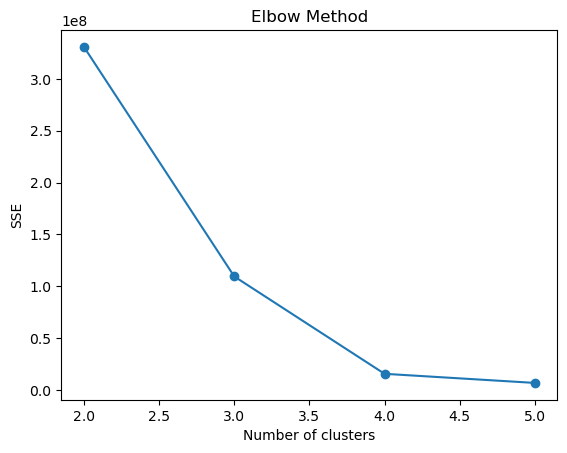

barrier       geo          c_birth                isced11  cluster
0         Austria  Foreign country  All ISCED 2011 levels        2
1         Belgium  Foreign country  All ISCED 2011 levels        2
2        Bulgaria  Foreign country  All ISCED 2011 levels        2
3         Croatia  Foreign country  All ISCED 2011 levels        2
4          Cyprus  Foreign country  All ISCED 2011 levels        2
barrier  Citizenship or residence permit  \
0                                 94.500   
1                                508.200   
2                                  4.168   

barrier  Discrimination due to foreign origin  Lack of language skills  \
0                                      85.300                   283.85   
1                                     571.750                  1836.35   
2                                      11.332                    37.74   

barrier  Lack of recognition of qualifications  \
0                                      255.100   
1                       

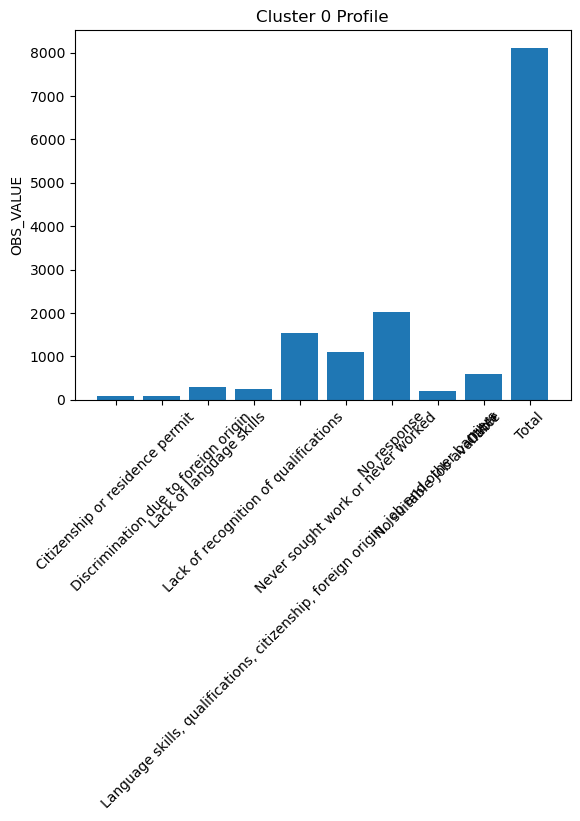

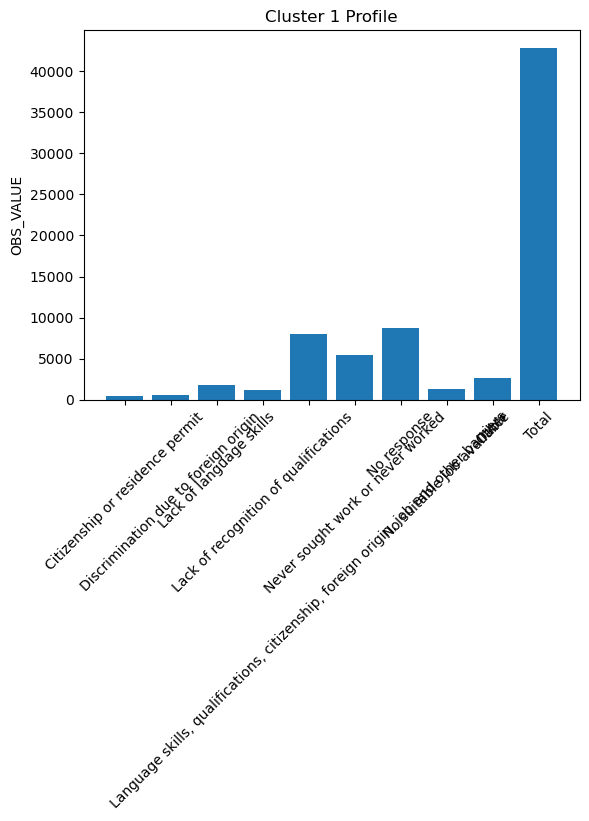

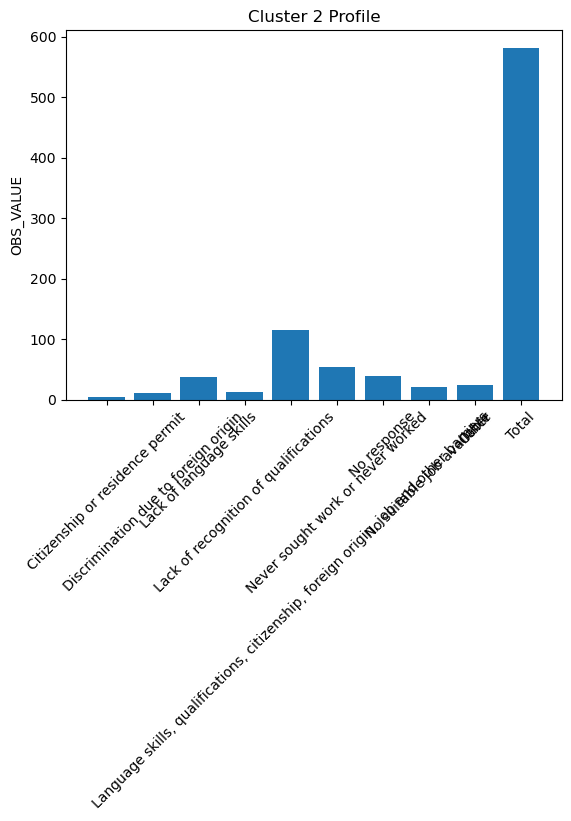

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('lfso_21obst01_page_linear.csv')

df = df[(df['TIME_PERIOD']==2021) & 
        (df['sex']=='Total') & 
        (df['age']=='From 15 to 74 years')]

df_grouped = df.pivot_table(
    index=['geo','c_birth','isced11'],
    columns='barrier',
    values='OBS_VALUE',
    fill_value=0
).reset_index()

feature_cols = df_grouped.columns[3:]
X = df_grouped[feature_cols].values

sse = []
for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.plot(range(2,6), sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df_grouped['cluster'] = kmeans.fit_predict(X)

print(df_grouped[['geo','c_birth','isced11','cluster']].head())

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
centroids['cluster'] = range(k)
print(centroids)

for i in range(k):
    plt.figure()
    plt.bar(feature_cols, centroids.iloc[i][feature_cols])
    plt.xticks(rotation=45)
    plt.ylabel('OBS_VALUE')
    plt.title(f'Cluster {i} Profile')
    plt.show()

df_grouped.to_csv('immigrant_obstacle_clusters.csv', index=False)
